In [1]:
import pandas as pd

data = {
    "Model": [
        "ResNet18",
        "ResNet34",
        "EfficientNet-B0",
        "EfficientNet-B3",
        "MobileNetV3-Large",
        "Hybrid Model"
    ],
    "Calories": [0.8574, 0.8567, 0.8450, 0.8324, 0.8771, 0.8798],
    "Mass":     [0.8903, 0.8972, 0.8536, 0.8615, 0.9020, 0.9284],
    "Fat":      [0.8221, 0.7886, 0.8492, 0.8426, 0.8850, 0.8795],
    "Carb":     [0.7539, 0.7590, 0.7862, 0.7973, 0.7980, 0.8205],
    "Protein":  [0.8495, 0.8392, 0.8610, 0.8905, 0.8941, 0.9276],
    "Mean_mAP": [0.8347, 0.8281, 0.8390, 0.8449, 0.8713, 0.8872]
}

df = pd.DataFrame(data)
df


,Model,Calories,Mass,Fat,Carb,Protein,Mean_mAP
0,ResNet18,0.8574,0.8903,0.8221,0.7539,0.8495,0.8347
1,ResNet34,0.8567,0.8972,0.7886,0.7590,0.8392,0.8281
2,EfficientNet-B0,0.8450,0.8536,0.8492,0.7862,0.8610,0.8390
3,EfficientNet-B3,0.8324,0.8615,0.8426,0.7973,0.8905,0.8449
4,MobileNetV3-Large,0.8771,0.9020,0.8850,0.7980,0.8941,0.8713
5,Hybrid Model,0.8798,0.9284,0.8795,0.8205,0.9276,0.8872


In [2]:
df_long = df.melt(
    id_vars="Model",
    value_vars=["Calories", "Mass", "Fat", "Carb", "Protein"],
    var_name="Nutrient",
    value_name="mAP"
)


/tmp/ipykernel_55/1111361725.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


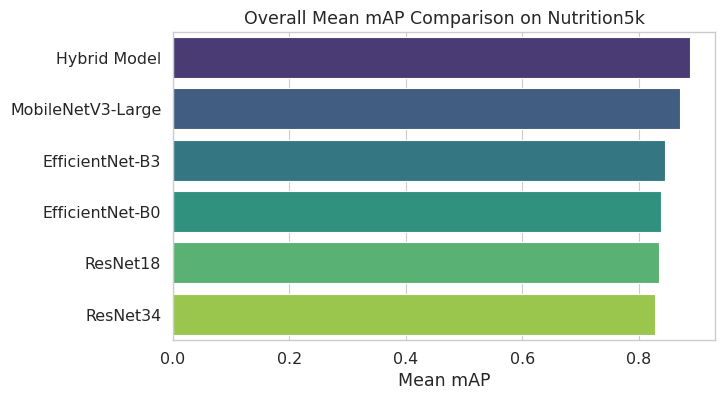

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.3)

plt.figure(figsize=(7,4))

sns.barplot(
    data=df.sort_values("Mean_mAP", ascending=False),
    x="Mean_mAP",
    y="Model",
    palette="viridis"
)

plt.xlabel("Mean mAP")
plt.ylabel("")
plt.title("Overall Mean mAP Comparison on Nutrition5k")

plt.show()


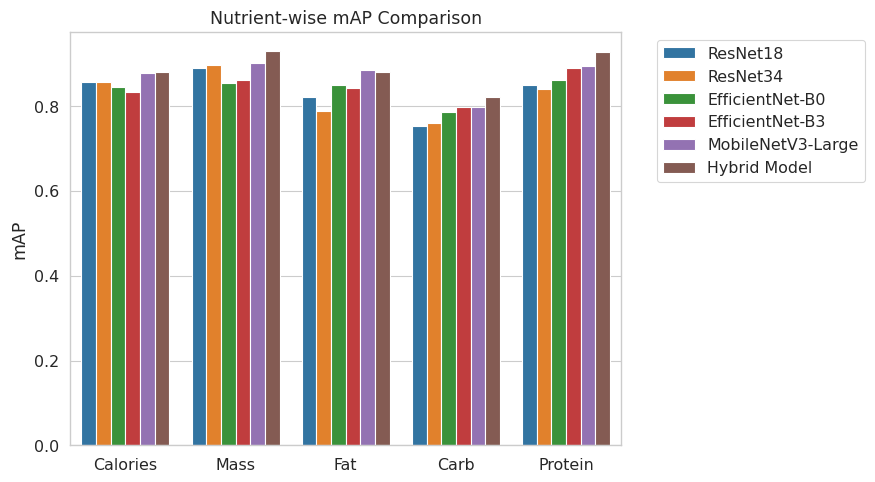

In [4]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=df_long,
    x="Nutrient",
    y="mAP",
    hue="Model",
    palette="tab10"
)

plt.title("Nutrient-wise mAP Comparison")
plt.xlabel("")
plt.ylabel("mAP")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


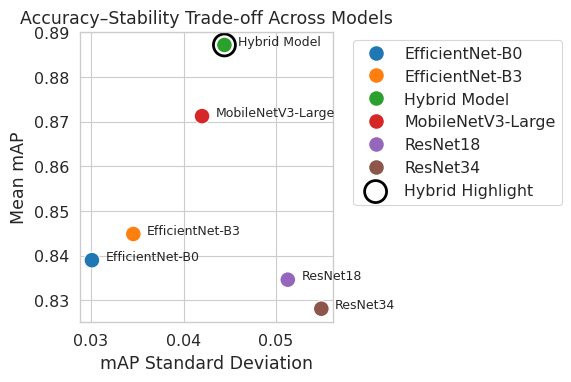

In [5]:
model_stats = df_long.groupby("Model")["mAP"].agg(["mean","std"]).reset_index()

plt.figure(figsize=(6,4))

sns.scatterplot(
    data=model_stats,
    x="std",
    y="mean",
    hue="Model",
    s=130,
    palette="tab10"
)

# Highlight Hybrid model
hybrid = model_stats[model_stats["Model"] == "Hybrid Model"]
plt.scatter(
    hybrid["std"],
    hybrid["mean"],
    s=250,
    edgecolor="black",
    facecolor="none",
    linewidth=2,
    label="Hybrid Highlight"
)

for _, row in model_stats.iterrows():
    plt.text(row["std"]+0.0015, row["mean"], row["Model"], fontsize=9)

plt.xlabel("mAP Standard Deviation")
plt.ylabel("Mean mAP")
plt.title("Accuracy–Stability Trade-off Across Models")

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


/tmp/ipykernel_55/3898425015.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_55/3898425015.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_55/3898425015.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_55/3898425015.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_55/3898425015.py:13: FutureWarning: 

Passing `pa

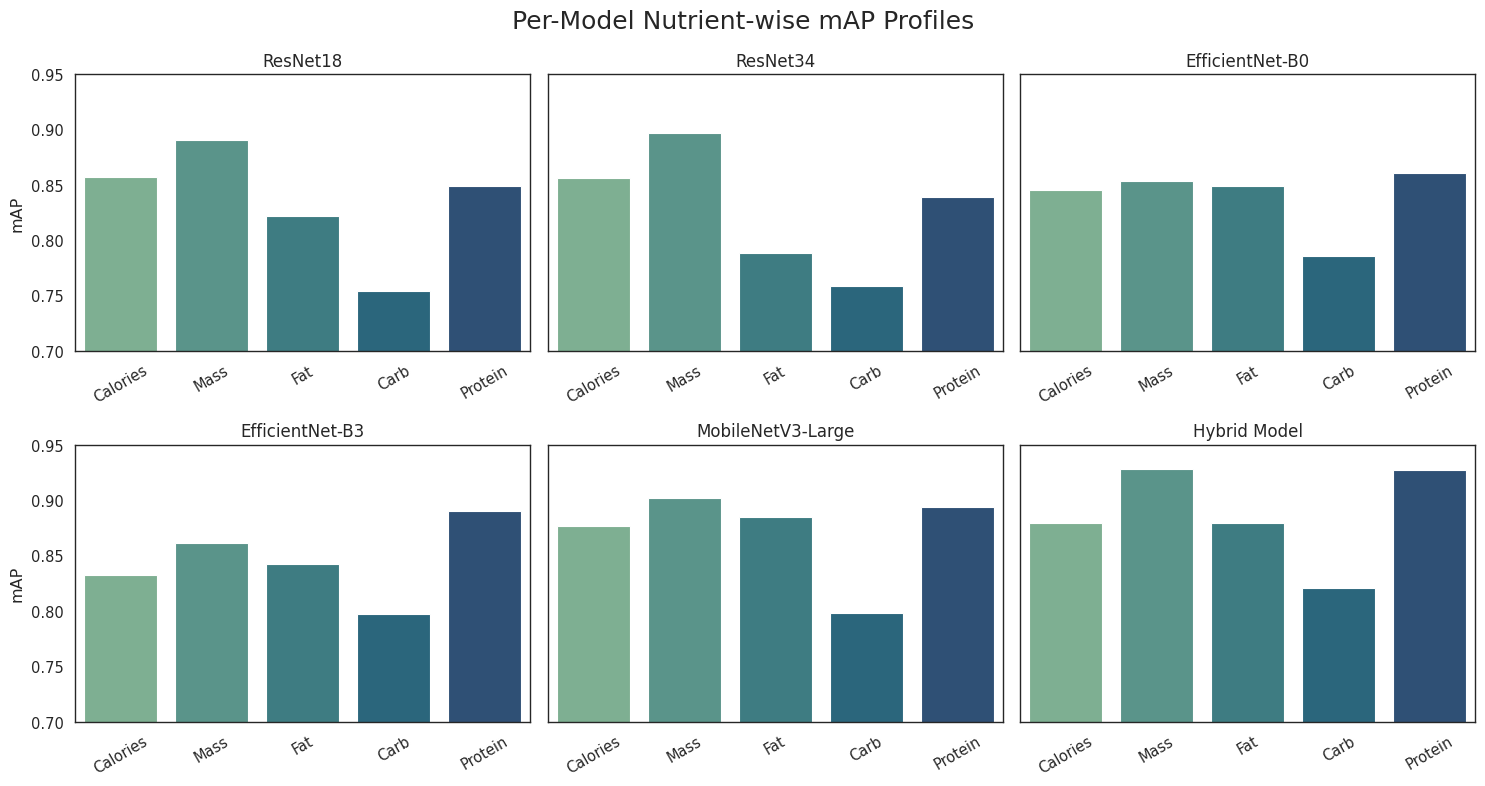

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", context="paper", font_scale=1.2)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
axes = axes.flatten()

nutrients = ["Calories", "Mass", "Fat", "Carb", "Protein"]

for ax, (_, row) in zip(axes, df.iterrows()):
    values = row[nutrients].values
    sns.barplot(
        x=nutrients,
        y=values,
        palette="crest",
        ax=ax
    )
    ax.set_title(row["Model"], fontsize=12)
    ax.set_ylim(0.7, 0.95)
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylabel("mAP")

plt.suptitle("Per-Model Nutrient-wise mAP Profiles", fontsize=18)
plt.tight_layout()
plt.show()


/tmp/ipykernel_55/889790650.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


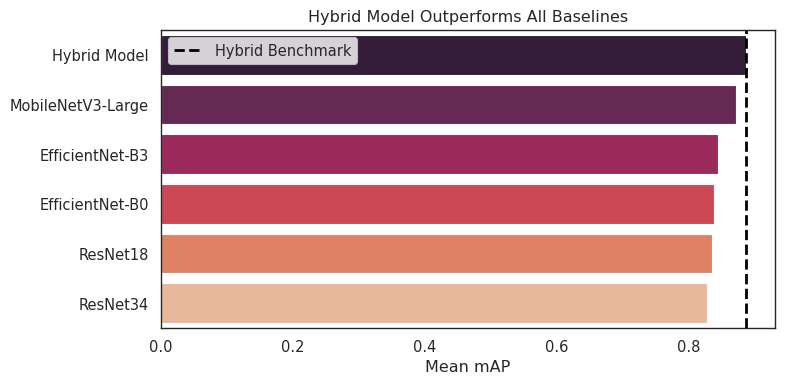

In [8]:
plt.figure(figsize=(8,4))

sns.barplot(
    data=df.sort_values("Mean_mAP", ascending=False),
    x="Mean_mAP",
    y="Model",
    palette="rocket"
)

plt.axvline(
    df[df["Model"] == "Hybrid Model"]["Mean_mAP"].values[0],
    color="black",
    linestyle="--",
    linewidth=2,
    label="Hybrid Benchmark"
)

plt.xlabel("Mean mAP")
plt.ylabel("")
plt.title("Hybrid Model Outperforms All Baselines")

plt.legend()
plt.tight_layout()
plt.show()


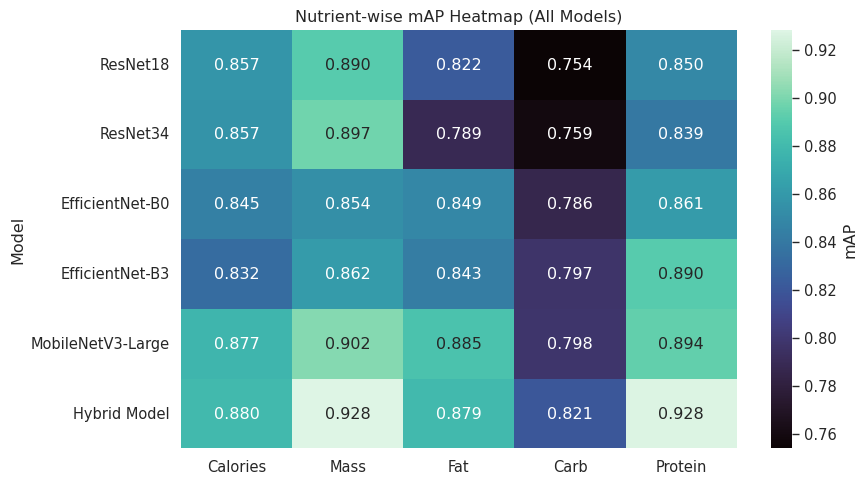

In [10]:
plt.figure(figsize=(9,5))
sns.heatmap(
    df.set_index("Model")[nutrients],
    annot=True,
    cmap="mako",
    fmt=".3f",
    cbar_kws={"label": "mAP"}
)

plt.title("Nutrient-wise mAP Heatmap (All Models)")
plt.tight_layout()
plt.show()
